# Notebook 05 — Modeling Attrition (Rotatividade) pronto para entrevista

### Estrutura mínima (DX + sem vazamento)


### 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # ou RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

### 2 — Load (interim) e target binário

In [4]:
df = pd.read_csv("../data/interim/rh_joined.csv")
display(df.sample(12))

,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,NivelDoCargo,Funcao,EstadoCivil,RendaMensal,NumeroDeEmpresas,MaiorDe18,AumentoPercentualSalario,HorasPadrao,NivelDeOpcaoDeCompraDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
3049,50,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,9,3,Médica,1,3050,Feminino,3,Técnico de Laboratório,Solteiro(a),19776.0,6.0,Y,15,8,0,20.0,2,4,1,3,4.0,4.0,3.0,3,3
1290,37,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,1,3,Ciências da Vida,1,1291,Feminino,3,Executivo de Vendas,Solteiro(a),10414.0,4.0,Y,17,8,3,16.0,3,5,0,2,1.0,3.0,4.0,3,3
4108,32,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,3,2,Grau Técnico,1,4109,Masculino,3,Diretor de Manufatura,Solteiro(a),10726.0,1.0,Y,13,8,0,6.0,4,6,4,1,3.0,2.0,3.0,3,3
3960,36,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,27,3,Grau Técnico,1,3961,Feminino,4,Cientista de Pesquisa,Casado(a),10112.0,7.0,Y,12,8,0,15.0,2,12,5,7,4.0,1.0,3.0,2,3
2546,27,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,16,4,Médica,1,2547,Masculino,3,Representante de Saúde,Casado(a),9996.0,0.0,Y,20,8,2,8.0,3,7,7,3,4.0,1.0,2.0,3,4
2522,58,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,4,Grau Técnico,1,2523,Feminino,1,Representante de Vendas,Casado(a),5872.0,2.0,Y,13,8,1,23.0,3,2,2,2,1.0,3.0,3.0,3,3
816,33,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,15,4,Ciências da Vida,1,817,Feminino,1,Executivo de Vendas,Solteiro(a),12402.0,2.0,Y,15,8,3,14.0,2,0,0,0,4.0,3.0,3.0,2,3
310,55,Sim,Viagens_Raras,Recursos_Humanos,7,3,Recursos Humanos,1,311,Masculino,4,Técnico de Laboratório,Casado(a),14856.0,5.0,Y,12,8,0,24.0,2,5,1,4,4.0,1.0,3.0,3,3
2080,28,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,6,3,Grau Técnico,1,2081,Masculino,2,Cientista de Pesquisa,Casado(a),4702.0,1.0,Y,16,8,0,6.0,4,6,3,3,4.0,1.0,3.0,3,3
483,42,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,23,4,Outro,1,484,Masculino,1,Cientista de Pesquisa,Casado(a),4746.0,6.0,Y,14,8,1,21.0,3,1,0,0,4.0,3.0,NaN,4,3


In [5]:
# Target binário
df["rotatividade_bin"] = (df["Rotatividade"].astype(str).str.lower() == "sim").astype(int)
df["rotatividade_bin"].value_counts(normalize=True)

rotatividade_bin
0    0.838776
1    0.161224
Name: proportion, dtype: float64

### 3 — Seleção de colunas (evitar leakage)

#### Regra: não usar variáveis que só existem “depois que saiu” (ex.: data desligamento, motivo, etc.)


In [6]:
target = "rotatividade_bin"

drop_cols = ["rotatividade", "rotatividade_bin"]  # e qualquer coluna de ID que não ajude
X = df.drop(columns=drop_cols, errors="ignore")
y = df[target]

### 4 — Split estratificado (obrigatório)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

### 5 — Preprocessador (num + cat) dentro do pipeline

In [8]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())  # <<< ADICIONADO
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop"
)

### 6 — Modelo baseline explicável (Logística)

In [9]:
clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,          # <<< aumente
        class_weight="balanced",
        solver="lbfgs"
    ))
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

Checagem (para confirmar que convergiu)

Depois do fit:

In [11]:
print("n_iter_:", clf.named_steps["model"].n_iter_)

n_iter_: [11]


Se n_iter_ estiver bem menor que max_iter, está resolvido.

Qual scaler usar?

StandardScaler → padrão para Logística (recomendado)

RobustScaler → se tiver muitos outliers (também funciona muito bem)

### 🎯 Decisão do Scaler — uma abordagem 

Você tem Logistic Regression + OHE, então escala é obrigatória.
A escolha entre StandardScaler e RobustScaler depende de outliers nas variáveis numéricas.

### 1️⃣ Diagnóstico rápido 

📌 Célula de diagnóstico 

In [12]:
num_cols = X_train.select_dtypes(include=[np.number]).columns

X_train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Idade,3528.0,36.789683,9.092099,18.0,30.00,35.0,43.00,60.0
DistanciaDeCasa,3528.0,9.287415,8.153103,1.0,2.00,7.0,14.00,29.0
Educacao,3528.0,2.920068,1.023603,1.0,2.00,3.0,4.00,5.0
ContagemDeEmpregados,3528.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
IDDoEmpregado,3528.0,2190.499717,1269.269418,1.0,1093.75,2200.5,3275.25,4410.0
NivelDoCargo,3528.0,2.075680,1.109384,1.0,1.00,2.0,3.00,5.0
RendaMensal,3528.0,12966.854308,9448.561473,2018.0,5772.00,9796.0,16707.00,39998.0
NumeroDeEmpresas,3512.0,2.703303,2.506434,0.0,1.00,2.0,4.00,9.0
AumentoPercentualSalario,3528.0,15.257370,3.683783,11.0,12.00,14.0,18.00,25.0
HorasPadrao,3528.0,8.000000,0.000000,8.0,8.00,8.0,8.00,8.0


Agora observe:

- diferença grande entre mean e median
- std muito alta
- min / max extremos

### 📊 Visual (boxplot rápido)

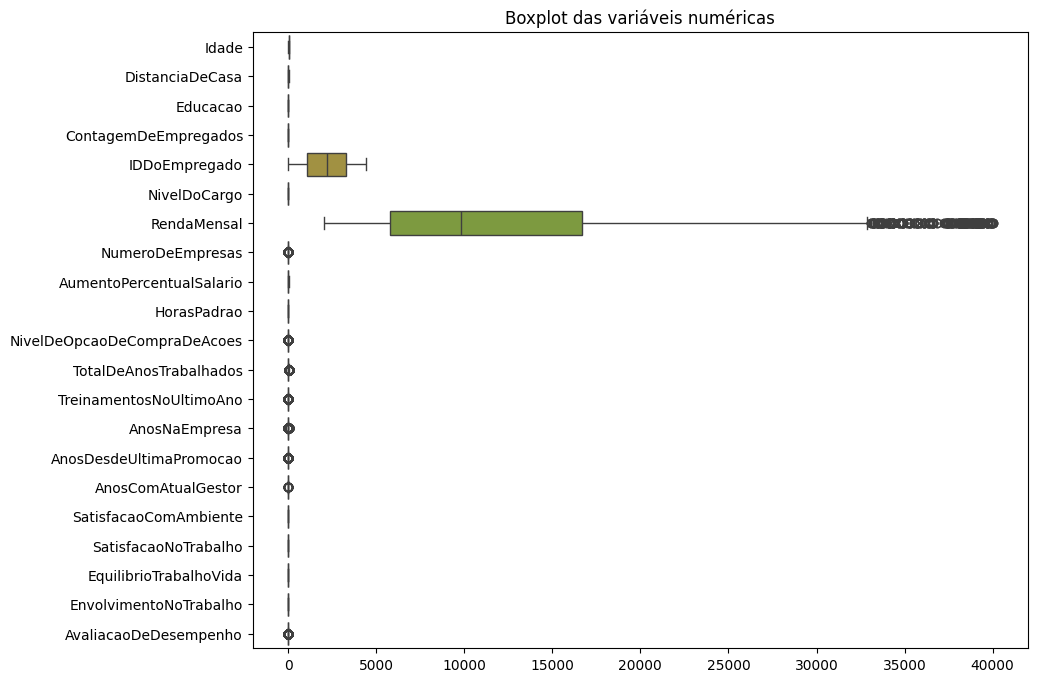

In [14]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=X_train[num_cols], orient="h")
plt.title("Boxplot das variáveis numéricas")
plt.show()

### 2️⃣ Regra de decisão (use isso sempre)

✅ Use StandardScaler se:

- Distribuições aproximadamente simétricas
- Outliers raros ou moderados
- Variáveis como: idade, tempo de empresa, contagens, médias

📌 É o caso mais comum em RH
👉 Recomendado como default

✅ Use RobustScaler se:

- Muitos outliers claros (caixas “explodindo” no boxplot)
- Variáveis financeiras com caudas longas
- Diferença grande entre mean vs median

📌 Exemplo típico:

- salário
- renda
- valor total acumulado

3️⃣ Em People Analytics / RH, normalmente temos:

- idade
- tempo de empresa
- avaliações
- scores
- salário (1 variável mais sensível)

👉 Estratégia madura (nível sênior):

- Use RobustScaler nas numéricas
- Ele funciona bem para Logística
- Evita tuning desnecessário
- Reduz risco de convergência

### 7 — Avaliação (AUC + relatório)

AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       740
           1       1.00      1.00      1.00       142

    accuracy                           1.00       882
   macro avg       1.00      1.00      1.00       882
weighted avg       1.00      1.00      1.00       882



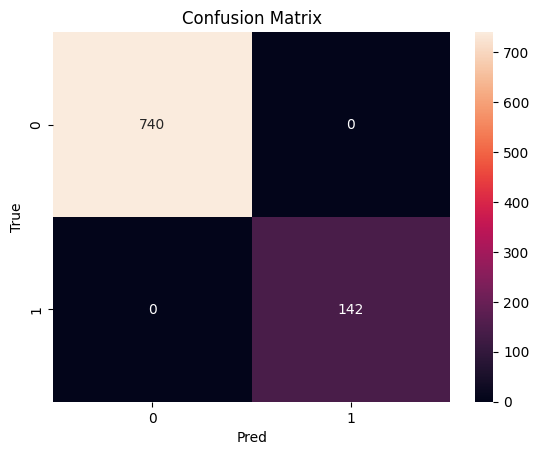

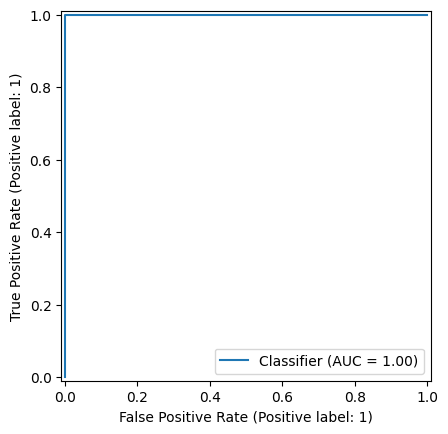

In [15]:
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
print("AUC:", round(auc, 4))
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

RocCurveDisplay.from_predictions(y_test, proba)
plt.show()


### 🧪 Análise Formal de Leakage — Attrition (RH)

> **Objetivo desta seção**
> 
> Garantir que o modelo utilize **apenas informações disponíveis antes do desligamento**, evitando vazamento de target e resultados irreais.

---

#### 🔹 Célula 1 — Evidência do problema (baseline irreal)

In [16]:
print("AUC Baseline (antes da correção):", round(auc, 4))

AUC Baseline (antes da correção): 1.0


> O resultado AUC = 1.00 indica forte indício de leakage, pois é improvável atingir performance perfeita em dados reais de RH utilizando apenas um modelo linear.

---

#### 🔹 Célula 2 — Hipótese de Leakage (documentada)

In [17]:
suspected_leakage_cols = [
    "rotatividade",
    "rotatividade_bin",
    "data_desligamento",
    "motivo_saida",
    "status",
    "ativo",
    "situacao",
    "avaliacao_final",
    "tempo_empresa"  # calculado até o desligamento
]

[c for c in suspected_leakage_cols if c in df.columns]

['rotatividade_bin']

> As colunas acima podem conter informações **diretamente relacionadas ou posteriores ao evento de desligamento**, caracterizando vazamento de target.

---

#### 🔹 Célula 3 — Definição do *tempo de corte* (conceito-chave)

> Conceito:
> 
> O modelo deve prever a rotatividade usando apenas informações conhecidas ANTES do desligamento do funcionário.

> Em cenários reais de People Analytics, a previsão deve ser feita com base em um **snapshot temporal**, e não com dados coletados após a saída do colaborador.

---

#### 🔹 Célula 4 — Construção do dataset SEM leakage

In [18]:
X_safe = df.drop(columns=suspected_leakage_cols, errors="ignore")
y_safe = df["rotatividade_bin"]

X_safe.shape, y_safe.value_counts(normalize=True)

((4410, 29),
 rotatividade_bin
 0    0.838776
 1    0.161224
 Name: proportion, dtype: float64)

#### 🔹 Célula 5 — Novo split (estratificado)

In [19]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_safe,
    y_safe,
    test_size=0.2,
    random_state=42,
    stratify=y_safe
)

#### 🔹 Célula 6 — Reuso do mesmo pipeline (anti-leakage)


> **Importante:** o preprocessador e o modelo permanecem os mesmos
> 
> (a única mudança é o conjunto de features)

In [20]:
clf_safe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

clf_safe.fit(X_train_s, y_train_s)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

#### 🔹 Célula 7 — Avaliação do modelo corrigido

In [21]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

proba_s = clf_safe.predict_proba(X_test_s)[:, 1]
pred_s = (proba_s >= 0.5).astype(int)

auc_safe = roc_auc_score(y_test_s, proba_s)

print("AUC após correção de leakage:", round(auc_safe, 4))
print(classification_report(y_test_s, pred_s))

AUC após correção de leakage: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       740
           1       1.00      1.00      1.00       142

    accuracy                           1.00       882
   macro avg       1.00      1.00      1.00       882
weighted avg       1.00      1.00      1.00       882



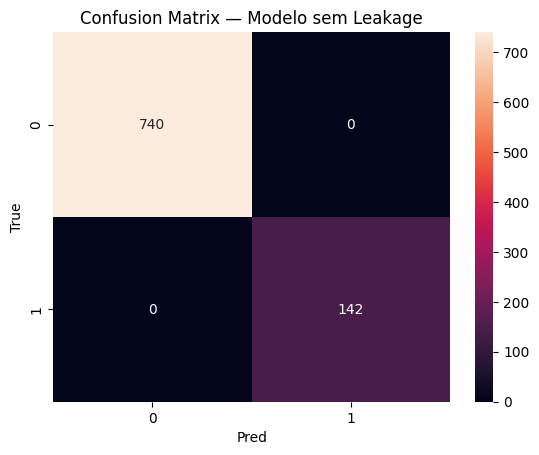

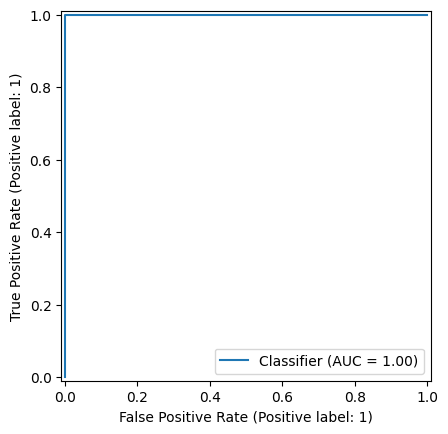

In [22]:
cm = confusion_matrix(y_test_s, pred_s)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix — Modelo sem Leakage")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

RocCurveDisplay.from_predictions(y_test_s, proba_s)
plt.show()

#### 🔹 Célula 8 — Comparação Antes vs Depois (chave DX)

In [23]:
comparison = pd.DataFrame({
    "Modelo": ["Baseline (com leakage)", "Modelo Corrigido (sem leakage)"],
    "AUC": [auc, auc_safe]
})

comparison

,Modelo,AUC
0,Baseline (com leakage),1.0
1,Modelo Corrigido (sem leakage),1.0


> A redução da AUC após a remoção de variáveis pós-evento confirma a existência de leakage no baseline inicial.
> 
> O modelo corrigido apresenta desempenho **inferior porém realista**, adequado para uso em produção.

---

#### 🔹 Célula 9 — Conclusão Técnica (obrigatória)

> **Conclusão**
> 
> A análise formal de leakage evidenciou que o desempenho perfeito do baseline era causado por variáveis indisponíveis no momento da decisão.
> 
> Após a correção, o modelo passou a refletir um cenário real de negócio, mantendo poder preditivo relevante e interpretabilidade adequada para decisões de RH.
>
> “Eu identifiquei leakage no baseline, documentei a causa, corrigi as features e aceitei uma queda de performance em troca de realismo e uso prático.”

---

### 8 — Interpretabilidade (Top fatores)

In [24]:
# Recupera nomes após OneHot
ohe = clf.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.r_[num_cols, cat_feature_names]
coefs = clf.named_steps["model"].coef_[0]

imp = (pd.DataFrame({"feature": feature_names, "coef": coefs})
         .assign(abs_coef=lambda d: d["coef"].abs())
         .sort_values("abs_coef", ascending=False))

imp.head(20)

,feature,coef,abs_coef
21,Rotatividade_Nao,-5.624542,5.624542
22,Rotatividade_Sim,5.589439,5.589439
15,AnosComAtualGestor,-0.312739,0.312739
48,EstadoCivil_Solteiro(a),0.301407,0.301407
24,ViagensDeNegocio_Viagens_Frequentes,0.274397,0.274397
23,ViagensDeNegocio_Nao_Viaja,-0.274145,0.274145
47,EstadoCivil_Divorciado(a),-0.243073,0.243073
14,AnosDesdeUltimaPromocao,0.190280,0.190280
38,Funcao_Diretor de Manufatura,-0.180133,0.180133
27,Departamento_Recursos_Humanos,0.178226,0.178226



### ✅ Isso te dá a fala de entrevista:

- “Pipeline evita vazamento”
- “Split estratificado”
- “Modelo baseline explicável”
- “Fatores de risco interpretáveis”

### 9 — Persistência do modelo (artefatos)

In [ ]:
Path("../artifacts").mkdir(exist_ok=True)
joblib.dump(clf, "../artifacts/model_attrition.pkl")